<a href="https://colab.research.google.com/github/eng-accelerator/ai-accelerator-C7/blob/main/Day%204/GEF_diffusers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# hf - a company

# libs - accelerate,

# transformers - based on the namw trans arch
# diffusion mechanism - behind image ml models
# diffusers - another lib by hf

In [ ]:
! pip install datasets evaluate transformers diffusers accelerate ftfy pyarrow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00


In [ ]:
import torch
from diffusers import (
    StableDiffusionPipeline, # text to image use-cases
    StableDiffusionImg2ImgPipeline # image to image use-cases
)

from PIL import Image
import requests
from io import BytesIO

torch_device = "cuda" if torch.cuda.is_available() else "cpu"

### Some examples

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

merges.txt: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

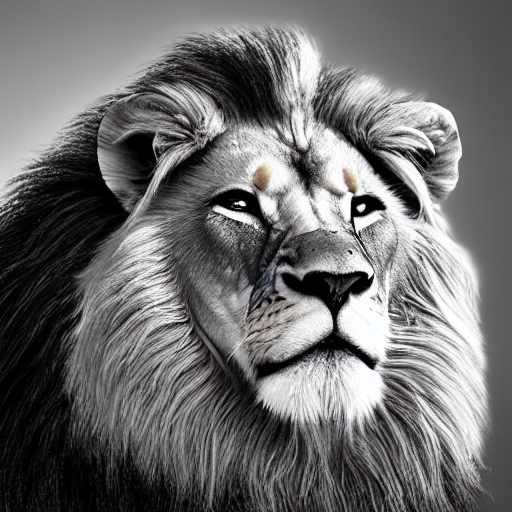

'\n📝 Parameters explained:\n- prompt: text description of the image\n- num_inference_steps: how many denoising steps (higher = better quality, slower)\n- guidance_scale: how strongly the prompt guides generation (7-8 is common; higher = more prompt fidelity, lower = more creativity)\n'

In [ ]:
# -------------------------------------
# 1. TEXT-TO-IMAGE GENERATION
# -------------------------------------


pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16
).to(torch_device) # pipe = model

# Example prompt
prompt = "A majestic lion wearing a crown, photorealistic, 4k, highly detailed" # set whatever
image = pipe(prompt, num_inference_steps=30, guidance_scale=7.5).images[0]

display(image)

# prompt 1 - toooo detailed, high guidance scale
# prompt 2 - not so detailed, low
"""
📝 Parameters explained:
- prompt: text description of the image
- num_inference_steps: how many denoising steps (higher = better quality, slower)
- guidance_scale: how strongly the prompt guides generation (7-8 is common; higher = more prompt fidelity, lower = more creativity)
"""



Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

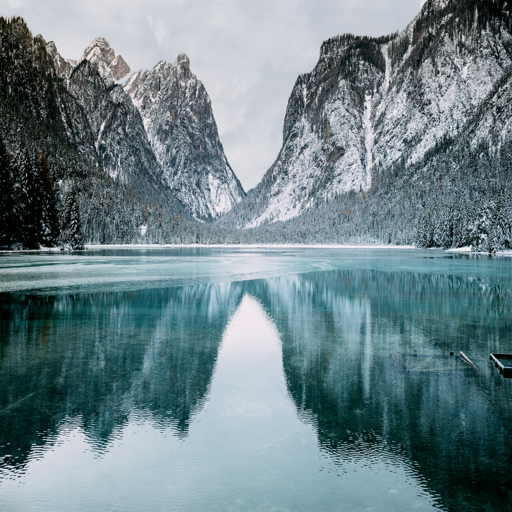

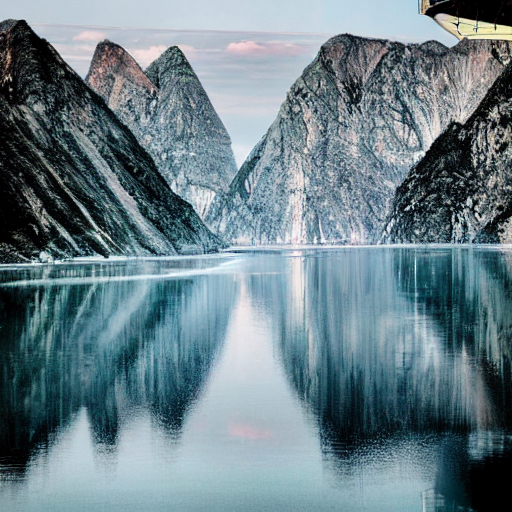

'\n📝 Parameters explained:\n- image: input image you want to transform\n- strength: controls how much noise is added\n    - low strength (0.2-0.4): keeps input structure, small edits\n    - high strength (0.7-0.9): more creative, diverges from input\n'

In [ ]:
# -------------------------------------
# 2. IMAGE-TO-IMAGE GENERATION
# -------------------------------------

img2img_pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16
).to(torch_device) # img2img_pipe = model


url = "https://images.unsplash.com/photo-1480497490787-505ec076689f?q=80&w=2069&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
init_image = Image.open(BytesIO(requests.get(url).content)).convert("RGB").resize((512, 512))

prompt = "A futuristic city skyline painted on the mountain"
strength = 0.7  # how much noise to add: 0 = almost same as input, 1 = ignore input
num_inference_steps = 40

img2img = img2img_pipe(
    prompt=prompt,
    image=init_image,
    strength=strength, # amt of noised added to the init img
    num_inference_steps=num_inference_steps, # bigger the number, more refined your image "might" be
    guidance_scale=7.5 # relates to the prompt - how much the model is gonna stick to the prompt
).images[0]

display(init_image)
display(img2img)

"""
📝 Parameters explained:
- image: input image you want to transform
- strength: controls how much noise is added
    - low strength (0.2-0.4): keeps input structure, small edits
    - high strength (0.7-0.9): more creative, diverges from input
"""

